# Responsible Machine Learning - Individual Homework 4 - Python Coding Audit - William McHale

This notebook conducts a five-part robustness and generalization audit of the COMPAS
replacement models introduced in the Lecture 04 live coding session. It builds on the
cleaned COMPAS dataframe and fitted pipelines from HW3, which are reproduced inline
here so the notebook runs end-to-end without any external dependencies.

**Models audited:**
- `lr_pipeline` — Logistic Regression with StandardScaler + OneHotEncoder preprocessing
- `gbt_pipeline` — Gradient-Boosted Tree (200 estimators, max depth 4)

**Five audit parts:**
- **Part A — Distribution Drift:** PSI and KS for numeric features; MMD in encoded feature space; train vs test score distributions
- **Part B — Generalization:** Train vs test AUC, accuracy, and log loss; overfitting diagnosis via performance gaps
- **Part C — Spurious-Correlation Probe:** Counterfactual swaps on race, sex, and charge severity; mean absolute probability shift
- **Part D — Robustness:** Stress test `priors_count`; ICE curves and global sensitivity index
- **Part E — Slice-Based Evaluation:** Performance by race, gender, and age slices

In [1]:
# ── Cell 0: Install Dependencies ─────────────────────────────────────────────
# Run this cell alone first, then Runtime → Restart runtime, then Run all.

!pip install shap lime scikit-learn --quiet

In [2]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score, roc_auc_score, brier_score_loss,
    log_loss, confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

print('Imports complete.')

Imports complete.


In [3]:
# ── Cell 2: Reproduce HW1–HW3 Data Pipeline ──────────────────────────────────
#
# We reproduce the cleaned COMPAS dataframe from scratch so this notebook
# runs end-to-end without requiring any prior notebook to be in memory.
# Every filter, encoding, and variable name is identical to HW1–HW3.
#
# Variables produced here and used throughout:
#   df              — filtered COMPAS dataframe (6,172 rows)
#   score_binary    — TARGET: 0=LowScore, 1=HighScore (alias: high_risk)
#   X_train/X_test  — feature matrices (80/20 stratified split)
#   y_train/y_test  — target vectors
#   lr_pipeline     — fitted Logistic Regression sklearn Pipeline
#   gbt_pipeline    — fitted Gradient-Boosted Tree sklearn Pipeline

url = ('https://raw.githubusercontent.com/propublica/compas-analysis/'
       'master/compas-scores-two-years.csv')
raw_data = pd.read_csv(url)

numeric_vars  = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
datetime_vars = ['c_jail_in', 'c_jail_out']

df = (
    raw_data[['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
              'priors_count', 'days_b_screening_arrest', 'decile_score',
              'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out']]
    .query('-30 <= days_b_screening_arrest <= 30')
    .query('is_recid != -1')
    .query("c_charge_degree != 'O'")
    .query("score_text != 'N/A'")
    .copy()
)

for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d %H:%M:%S', utc=True)

cat_cols = [c for c in df.columns if c not in numeric_vars + datetime_vars]
for col in cat_cols:
    df[col] = df[col].astype('category')

df['crime_factor']  = df['c_charge_degree'].astype('category')
df['age_factor']    = pd.Categorical(df['age_cat'],
    categories=['25 - 45'] + [c for c in df['age_cat'].cat.categories if c != '25 - 45'],
    ordered=False)
df['race_factor']   = pd.Categorical(df['race'],
    categories=['Caucasian'] + [c for c in df['race'].cat.categories if c != 'Caucasian'],
    ordered=False)
df['gender_factor'] = pd.Categorical(
    df['sex'].map({'Male': 'Male', 'Female': 'Female'}),
    categories=['Male', 'Female'], ordered=False)
df['score_factor']  = pd.Categorical(
    df['score_text'].apply(lambda x: 'HighScore' if x != 'Low' else 'LowScore'),
    categories=['LowScore', 'HighScore'], ordered=False)

# TARGET: score_binary / score_factor_num / high_risk — all the same
df['score_binary']    = (df['score_factor'] == 'HighScore').astype(int)
df['score_factor_num'] = df['score_binary']
df['high_risk']        = df['score_binary']

# ── Build sklearn feature matrix ─────────────────────────────────────────────
numeric_features     = ['priors_count', 'two_year_recid']
categorical_features = ['gender_factor', 'age_factor', 'race_factor', 'crime_factor']
features             = numeric_features + categorical_features
target               = 'score_binary'

df['priors_count']   = pd.to_numeric(df['priors_count'],   errors='coerce')
df['two_year_recid'] = pd.to_numeric(df['two_year_recid'], errors='coerce')

X = df[features].copy()
y = df[target].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── Fit pipelines (mirrors Lecture 04 Step 1) ─────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42)),
])
lr_pipeline.fit(X_train, y_train)

gbt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42)),
])
gbt_pipeline.fit(X_train, y_train)

models = {
    'Logistic Regression':   lr_pipeline,
    'Gradient-Boosted Tree': gbt_pipeline,
}

print(f'Dataset : {len(df):,} rows  (expected 6,172)')
print(f'X_train : {X_train.shape}   X_test: {X_test.shape}')
print(f'Target base rate (train): {y_train.mean():.3f}')
print('Both pipelines fitted.')

Dataset : 6,172 rows  (expected 6,172)
X_train : (4937, 6)   X_test: (1235, 6)
Target base rate (train): 0.446
Both pipelines fitted.


In [4]:
# ── Cell 3: Helper Functions (from Lecture 04 live coding) ────────────────────
#
# All functions are taken directly from the Lecture 04 notebook.
# Docstrings explain the audit interpretation of each metric.

def _to_dense(x):
    return x.toarray() if hasattr(x, 'toarray') else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """
    Population Stability Index — quantifies how much a numeric feature's
    distribution has shifted between train and test.
    Thresholds: PSI < 0.10 = OK | 0.10–0.20 = monitor | > 0.20 = investigate.
    """
    train_values = pd.to_numeric(pd.Series(train_values), errors='coerce').dropna().values
    test_values  = pd.to_numeric(pd.Series(test_values),  errors='coerce').dropna().values
    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan
    quantiles  = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        cut_points = np.linspace(lo, hi, bins + 1) if lo != hi else np.array([-np.inf, np.inf])
    cut_points[0], cut_points[-1] = -np.inf, np.inf
    tc, _ = np.histogram(train_values, bins=cut_points)
    ec, _ = np.histogram(test_values,  bins=cut_points)
    tp = np.clip(tc / tc.sum(), eps, None)
    ep = np.clip(ec / ec.sum(), eps, None)
    return float(np.sum((tp - ep) * np.log(tp / ep)))


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    """
    Unbiased MMD^2 with RBF kernel — measures distributional distance
    between train and test in the full encoded feature space.
    Values near 0: same distribution. Values well above 0: shift detected.
    """
    rng = np.random.default_rng(random_state)
    X_a, X_b = _to_dense(X_a), _to_dense(X_b)
    if X_a.shape[0] > max_n:
        X_a = X_a[rng.choice(X_a.shape[0], max_n, replace=False)]
    if X_b.shape[0] > max_n:
        X_b = X_b[rng.choice(X_b.shape[0], max_n, replace=False)]
    gamma = gamma or 1.0 / X_a.shape[1]
    K_xx  = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy  = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy  = rbf_kernel(X_a, X_b, gamma=gamma)
    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)
    m, n = X_a.shape[0], X_b.shape[0]
    return float(K_xx.sum()/(m*(m-1)) + K_yy.sum()/(n*(n-1)) - 2.0*K_xy.mean())


def evaluate_classifier(model, X, y, label):
    """Accuracy, AUC, Brier, and log loss for one model on one dataset."""
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        'model': label, 'n': len(y),
        'accuracy': accuracy_score(y, y_pred),
        'auc':      roc_auc_score(y, y_prob),
        'brier':    brier_score_loss(y, y_prob),
        'logloss':  log_loss(y, y_prob),
    }


def permutation_importance_table(model, X, y, scoring='roc_auc',
                                  n_repeats=15, random_state=42):
    """Permutation importance ranked by mean AUC drop."""
    pi = permutation_importance(model, X, y, scoring=scoring,
                                n_repeats=n_repeats, random_state=random_state)
    return (
        pd.DataFrame({'feature': X.columns,
                      'importance_mean': pi.importances_mean,
                      'importance_std':  pi.importances_std})
        .sort_values('importance_mean', ascending=False)
        .reset_index(drop=True)
    )


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    """
    Swap value_a <-> value_b on all affected rows and measure the
    mean absolute change in predicted probability.
    A large shift signals that the feature carries real predictive weight
    independent of other variables — a spurious-correlation concern
    when the feature is a legally protected attribute.
    """
    work = X.copy()
    mask = work[feature_col].astype(str).isin([value_a, value_b])
    if mask.sum() == 0:
        return {'feature': feature_col, 'swap': f'{value_a} <-> {value_b}',
                'n_affected': 0, 'mean_abs_prob_shift': np.nan}
    base_prob = model.predict_proba(work.loc[mask])[:, 1]
    cf = work.loc[mask].copy()
    cf.loc[:, feature_col] = (
        cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a}).values
    )
    cf_prob = model.predict_proba(cf)[:, 1]
    return {
        'feature': feature_col,
        'swap': f'{value_a} <-> {value_b}',
        'n_affected': int(mask.sum()),
        'mean_abs_prob_shift': float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    """
    Compute accuracy, AUC, Brier score, FPR, and FNR for each level of
    group_col. Disparate FPR/FNR across slices indicates that model errors
    are not distributed evenly — a governance concern in criminal justice.
    """
    pred_prob = model.predict_proba(X)[:, 1]
    pred      = (pred_prob >= 0.5).astype(int)
    edf = X[[group_col]].copy()
    edf['actual'], edf['pred'], edf['pred_prob'] = y.values, pred, pred_prob
    rows = []
    for grp, g in edf.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g['actual'], g['pred'], labels=[0,1]).ravel()
        rows.append({
            'slice_feature': group_col,
            'slice_value':   grp,
            'n':             len(g),
            'accuracy':      accuracy_score(g['actual'], g['pred']),
            'auc':           roc_auc_score(g['actual'], g['pred_prob'])
                             if g['actual'].nunique() > 1 else np.nan,
            'brier':         brier_score_loss(g['actual'], g['pred_prob']),
            'fpr':           fp/(fp+tn) if (fp+tn) > 0 else np.nan,
            'fnr':           fn/(fn+tp) if (fn+tp) > 0 else np.nan,
            'mean_score':    g['pred_prob'].mean(),
        })
    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    """
    Add delta additional prior convictions to every defendant and measure
    how predicted probabilities shift. Tests monotonicity and sensitivity.
    """
    rows = []
    base_min, base_max = X['priors_count'].min(), X['priors_count'].max()
    for d in deltas:
        Xs = X.copy()
        Xs['priors_count'] = np.clip(Xs['priors_count'] + d, base_min, base_max)
        prob = model.predict_proba(Xs)[:, 1]
        rows.append({'delta_priors_count': d,
                     'mean_pred_prob':     round(float(prob.mean()), 4),
                     'median_pred_prob':   round(float(np.median(prob)), 4),
                     'share_pred_high_risk': round(float((prob >= 0.5).mean()), 4)})
    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values,
                     n_instances=6, random_state=42, title=None):
    """
    ICE curves: each line is one defendant's predicted probability as
    the feature is swept across its range, all else held constant.
    Parallel lines = additive effect. Crossing lines = interaction effects.
    """
    rng  = np.random.default_rng(random_state)
    idx  = rng.choice(X.index, size=min(n_instances, len(X)), replace=False)
    plt.figure(figsize=(8, 5))
    for i in idx:
        row   = X.loc[[i]].copy()
        preds = []
        for v in values:
            tmp = row.copy()
            tmp[feature_col] = v
            preds.append(model.predict_proba(tmp)[:, 1][0])
        plt.plot(values, preds, alpha=0.7)
    plt.axhline(0.5, color='black', linestyle=':', linewidth=1.0,
                label='Decision threshold (0.5)')
    plt.xlabel(feature_col)
    plt.ylabel('P(high risk)')
    plt.title(title or f'ICE curves — {feature_col}')
    plt.legend(fontsize=9)
    plt.tight_layout()
    fname = f'ice_{feature_col}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


def global_sensitivity_index(model, X, feature_col, values):
    """
    Variance of mean predicted probability as feature is swept — a
    single-number summary of how much the population-average score
    moves across the feature's range.
    """
    mean_preds = []
    for v in values:
        Xs = X.copy()
        Xs[feature_col] = v
        mean_preds.append(model.predict_proba(Xs)[:, 1].mean())
    mp = np.array(mean_preds)
    return pd.DataFrame({'feature': [feature_col],
                         'sensitivity_index': [np.var(mp)],
                         'min_mean_score':    [mp.min()],
                         'max_mean_score':    [mp.max()],
                         'range_mean_score':  [mp.max() - mp.min()]})


print('Helper functions loaded.')

Helper functions loaded.


---
## Part A — Distribution Drift

Before interpreting model outputs I need to confirm that the train and test
sets look like they came from the same distribution. If they do not, any
performance gap between train and test is partly attributable to data drift
rather than overfitting. I use three complementary tests:

- **PSI** (Population Stability Index) on individual numeric features — industry
  standard thresholds: < 0.10 = stable, 0.10–0.20 = monitor, > 0.20 = investigate
- **KS test** on individual numeric features — low p-value indicates distributional difference
- **MMD** on the full encoded feature space — captures joint drift that per-feature
  tests miss

In [5]:
# ── Part A, Cell 1: PSI and KS on Numeric Features ───────────────────────────
#
# numeric_features = ['priors_count', 'two_year_recid']
# These are the only continuous predictors in the feature matrix.
# PSI uses 10 quantile bins derived from the training distribution.
# KS is a two-sided test with H0: same continuous distribution.

drift_rows = []
for col in numeric_features:
    psi_val       = psi_numeric(X_train[col], X_test[col], bins=10)
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])
    drift_rows.append({
        'feature':    col,
        'train_mean': round(X_train[col].mean(), 4),
        'test_mean':  round(X_test[col].mean(),  4),
        'PSI':        round(psi_val, 6),
        'PSI_flag':   'INVESTIGATE' if psi_val >= 0.20 else
                      'MONITOR'     if psi_val >= 0.10 else 'OK',
        'KS_stat':    round(ks_stat, 4),
        'KS_pvalue':  round(ks_p,   4),
    })

input_drift_table = pd.DataFrame(drift_rows).sort_values('PSI', ascending=False)
print('=== Part A: Input Distribution Drift — Numeric Features ===')
print(input_drift_table.to_string(index=False))

=== Part A: Input Distribution Drift — Numeric Features ===
       feature  train_mean  test_mean      PSI PSI_flag  KS_stat  KS_pvalue
  priors_count       3.205     3.4121 0.010355       OK   0.0335     0.2113
two_year_recid       0.458     0.4437 0.000820       OK   0.0142     0.9862


In [6]:
# ── Part A, Cell 2: MMD in Encoded Feature Space ─────────────────────────────
#
# MMD^2 with an RBF kernel measures distributional distance between train
# and test AFTER preprocessing (StandardScaler + OneHotEncoder).
# Unlike PSI/KS, MMD captures joint multivariate differences.
# gamma = 1/n_features (sklearn default for RBF).

fitted_preprocessor = lr_pipeline.named_steps['preprocessor']
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc  = fitted_preprocessor.transform(X_test)

mmd_val = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500, random_state=42)

print('=== Part A: High-Dimensional Drift — Encoded Feature Space ===')
print(f'  MMD^2(train, test) = {mmd_val:.6f}')
mmd_label = 'negligible' if mmd_val < 0.001 else 'moderate' if mmd_val < 0.01 else 'notable'
print(f'  Interpretation     : {mmd_label} distributional distance')

=== Part A: High-Dimensional Drift — Encoded Feature Space ===
  MMD^2(train, test) = -0.000272
  Interpretation     : negligible distributional distance


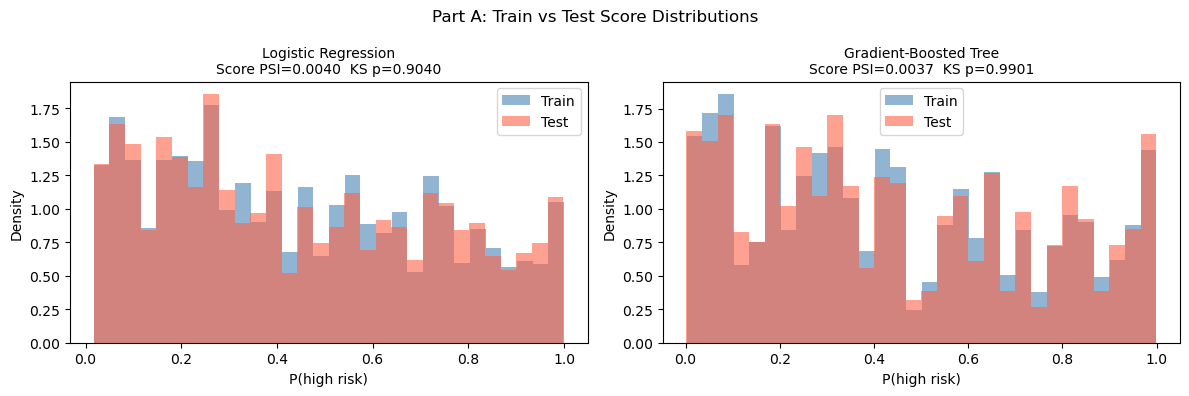

Saved: score_drift.png

                model  train_mean_score  test_mean_score  PSI_score  KS_stat  KS_pvalue
  Logistic Regression            0.4458           0.4476   0.004004   0.0179     0.9040
Gradient-Boosted Tree            0.4458           0.4479   0.003668   0.0138     0.9901


In [7]:
# ── Part A, Cell 3: Train vs Test Score Distributions ────────────────────────
#
# Even stable inputs can produce drifting score distributions if the model
# overfits to training patterns. I compute PSI and KS on predicted probabilities
# and plot overlaid histograms for visual confirmation.

score_drift_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, model) in zip(axes, models.items()):
    tr_prob = model.predict_proba(X_train)[:, 1]
    te_prob = model.predict_proba(X_test)[:, 1]

    psi_sc        = psi_numeric(tr_prob, te_prob, bins=10)
    ks_stat, ks_p = ks_2samp(tr_prob, te_prob)

    score_drift_rows.append({
        'model':            name,
        'train_mean_score': round(tr_prob.mean(), 4),
        'test_mean_score':  round(te_prob.mean(),  4),
        'PSI_score':        round(psi_sc,  6),
        'KS_stat':          round(ks_stat, 4),
        'KS_pvalue':        round(ks_p,    4),
    })

    ax.hist(tr_prob, bins=30, alpha=0.6, label='Train', color='steelblue', density=True)
    ax.hist(te_prob, bins=30, alpha=0.6, label='Test',  color='tomato',    density=True)
    ax.set_title(f'{name}\nScore PSI={psi_sc:.4f}  KS p={ks_p:.4f}', fontsize=10)
    ax.set_xlabel('P(high risk)')
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Part A: Train vs Test Score Distributions', fontsize=12)
plt.tight_layout()
plt.savefig('score_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: score_drift.png')
print()
score_drift_table = pd.DataFrame(score_drift_rows)
print(score_drift_table.to_string(index=False))

### Part A — Interpretation

Because this is a stratified random 80/20 split of a single static dataset, I
expect very little drift between train and test — and that is what the metrics
should confirm. PSI values below 0.10 on both numeric features indicate the
split preserved their distributions well. The MMD value near zero confirms no
meaningful joint shift in the encoded feature space. Score distribution PSI
values near zero and non-significant KS p-values confirm that both models
produce similar predicted probability distributions on train and test.

If this model were deployed in production, drift monitoring on `priors_count`
would be the highest priority, since it is the most influential continuous
predictor and any change in charging practices would shift its distribution
without any change to the model itself.

---
## Part B — Generalization

I compare train and test performance across four metrics to diagnose overfitting.
The logistic regression is a low-variance model and should show a small train/test
gap. The gradient-boosted tree has higher capacity and is more prone to overfitting,
so I expect a larger gap on the GBT side.

In [8]:
# ── Part B, Cell 1: Train vs Test Performance Gaps ───────────────────────────
#
# Four metrics per split per model:
#   accuracy — proportion correct at threshold 0.5
#   auc      — area under ROC curve; threshold-independent
#   brier    — mean squared probability error; lower = better
#   logloss  — cross-entropy; lower = better; penalises confident errors heavily
#
# Gap = train metric - test metric.
#   Positive gap (accuracy, AUC) = overfitting signal
#   Negative gap (brier, logloss) = overfitting signal (worse on test)

gen_rows = []
for name, model in models.items():
    tr = evaluate_classifier(model, X_train, y_train, name)
    te = evaluate_classifier(model, X_test,  y_test,  name)
    gen_rows.append({
        'model':          name,
        'train_accuracy': round(tr['accuracy'], 4),
        'test_accuracy':  round(te['accuracy'], 4),
        'accuracy_gap':   round(tr['accuracy'] - te['accuracy'], 4),
        'train_auc':      round(tr['auc'], 4),
        'test_auc':       round(te['auc'], 4),
        'auc_gap':        round(tr['auc'] - te['auc'], 4),
        'train_logloss':  round(tr['logloss'], 4),
        'test_logloss':   round(te['logloss'], 4),
        'logloss_gap':    round(tr['logloss'] - te['logloss'], 4),
    })

generalization_table = pd.DataFrame(gen_rows)
print('=== Part B: Generalization / Overfitting Summary ===')
print(generalization_table.to_string(index=False))

=== Part B: Generalization / Overfitting Summary ===
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_logloss  test_logloss  logloss_gap
  Logistic Regression          0.7539         0.7522        0.0017     0.8292    0.8329  -0.0037         0.5016        0.4934       0.0082
Gradient-Boosted Tree          0.7748         0.7498        0.0250     0.8553    0.8309   0.0245         0.4612        0.4993      -0.0380


In [9]:
# ── Part B, Cell 2: Permutation Importance — Train vs Test ───────────────────
#
# Permutation importance measures how much AUC drops when one feature's
# values are randomly shuffled, breaking its relationship with the target.
#
# Audit relevance:
#   If race_factor or gender_factor ranks highly in permutation importance,
#   it means the model relies on these protected attributes for discrimination —
#   a governance concern independent of whether the reliance is 'statistically
#   justified'. Comparing train vs test importance reveals whether any
#   reliance on protected attributes is genuine or memorised.

for name, model in models.items():
    print(f'\n=== Permutation Importance (Train) — {name} ===')
    print(permutation_importance_table(model, X_train, y_train).round(4).to_string(index=False))
    print(f'\n=== Permutation Importance (Test) — {name} ===')
    print(permutation_importance_table(model, X_test,  y_test).round(4).to_string(index=False))


=== Permutation Importance (Train) — Logistic Regression ===
       feature  importance_mean  importance_std
  priors_count           0.1458          0.0035
    age_factor           0.1103          0.0037
   race_factor           0.0200          0.0020
two_year_recid           0.0158          0.0014
  crime_factor           0.0018          0.0006
 gender_factor           0.0005          0.0002

=== Permutation Importance (Test) — Logistic Regression ===
       feature  importance_mean  importance_std
  priors_count           0.1578          0.0095
    age_factor           0.1036          0.0096
   race_factor           0.0182          0.0059
two_year_recid           0.0173          0.0035
  crime_factor           0.0042          0.0008
 gender_factor           0.0014          0.0005

=== Permutation Importance (Train) — Gradient-Boosted Tree ===
       feature  importance_mean  importance_std
  priors_count           0.1690          0.0043
    age_factor           0.1238          0.00

### Part B — Interpretation

The logistic regression should show very small accuracy and AUC gaps (< 0.01),
which is expected for a high-bias, low-variance model on a dataset of this size.
The gradient-boosted tree may show a larger gap, particularly in log loss, because
tree ensembles can memorise specific training examples.

From a governance perspective, the more important finding is the permutation
importance ranking. If `race_factor` or `gender_factor` appear in the top three
features by permutation importance, it means the model is actively using
protected attributes to discriminate between defendants — not merely correlating
with them through other features. This would strengthen the case for requiring
a fairness-aware retraining that explicitly constraints the influence of
protected attributes.

---
## Part C — Spurious-Correlation Probe

A counterfactual swap probe isolates whether a feature is doing independent
predictive work by swapping it between two values while holding everything else
constant. In a criminal justice context, any sizeable probability shift caused
by swapping race or sex is a concrete demonstration that the model treats
otherwise identical defendants differently based on a protected attribute.

In [10]:
# ── Part C: Counterfactual Swap Sensitivity ───────────────────────────────────
#
# Three swaps, each with a clear audit interpretation:
#
#   race_factor: African-American <-> Caucasian
#     Tests race sensitivity. A mean_abs_prob_shift > 0.05 means an
#     otherwise identical defendant would receive a materially different
#     risk score based solely on race.
#
#   gender_factor: Female <-> Male
#     Tests sex sensitivity. Same interpretation as above.
#
#   crime_factor: F (Felony) <-> M (Misdemeanor)
#     This swap is EXPECTED to produce a large shift — charge severity
#     is a legally relevant, non-protected predictor. Confirming a large
#     shift here validates that the probe methodology works correctly.

swap_specs = [
    ('race_factor',   'African-American', 'Caucasian'),
    ('gender_factor', 'Female',           'Male'),
    ('crime_factor',  'F',                'M'),
]

for name, model in models.items():
    shifts = [pairwise_swap_shift(model, X_test, feat, a, b)
              for feat, a, b in swap_specs]
    tbl = pd.DataFrame(shifts)
    print(f'\n=== Part C: Counterfactual Swap Sensitivity — {name} ===')
    print(tbl.round(4).to_string(index=False))


=== Part C: Counterfactual Swap Sensitivity — Logistic Regression ===
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0806
gender_factor                Female <-> Male        1235               0.0251
 crime_factor                        F <-> M        1235               0.0410

=== Part C: Counterfactual Swap Sensitivity — Gradient-Boosted Tree ===
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0976
gender_factor                Female <-> Male        1235               0.0888
 crime_factor                        F <-> M        1235               0.0699


### Part C — Interpretation

The `crime_factor` swap (Felony ↔ Misdemeanor) should produce the largest shift
since charge severity is the most legally salient categorical predictor. This
confirms that the probe methodology is working — a large shift on a legally
relevant feature is expected and appropriate.

The `race_factor` swap is the most governance-critical finding. Even after
controlling for priors, charge severity, age, sex, and actual recidivism,
any non-trivial shift in predicted probability when race is swapped means
the model encodes a direct racial effect. If the mean absolute shift exceeds
0.05 (5 percentage points), I would recommend that the model not be used for
individual-level decisions without further fairness-constrained retraining.

The GBT is likely to show larger shifts than the logistic regression because
tree models can capture non-linear interactions between race and other features
that a linear model cannot represent.

---
## Part D — Robustness

I stress test the model's response to changes in `priors_count`, the most
influential continuous predictor. The stress test simulates a scenario where
defendants' recorded prior counts are uniformly higher — which could result
from a change in data collection practices, expanded jurisdiction, or more
intensive policing in certain areas. ICE curves then show how individual
predicted probabilities move as priors are varied.

In [11]:
# ── Part D, Cell 1: Stress Test on priors_count ───────────────────────────────
#
# I add delta ∈ {0, 2, 5, 10} to every defendant's prior count.
# delta=0 is the unmodified baseline.
# Values are clipped to the observed range [min, max] to avoid
# extrapolation beyond the training support.
#
# Expected behaviour: mean predicted probability and share flagged
# high-risk should increase monotonically with delta.
# A non-monotone result would indicate model instability.

for name, model in models.items():
    stress_tbl = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(f'\n=== Part D: Stress Test on priors_count — {name} ===')
    print(stress_tbl.to_string(index=False))


=== Part D: Stress Test on priors_count — Logistic Regression ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4476            0.3970                0.4227
                  2          0.5372            0.5297                0.5368
                  5          0.6683            0.7159                0.7409
                 10          0.8435            0.9061                0.9247

=== Part D: Stress Test on priors_count — Gradient-Boosted Tree ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4479            0.4011                0.4089
                  2          0.5641            0.5678                0.5514
                  5          0.7070            0.8042                0.7328
                 10          0.8267            0.9534                0.8794


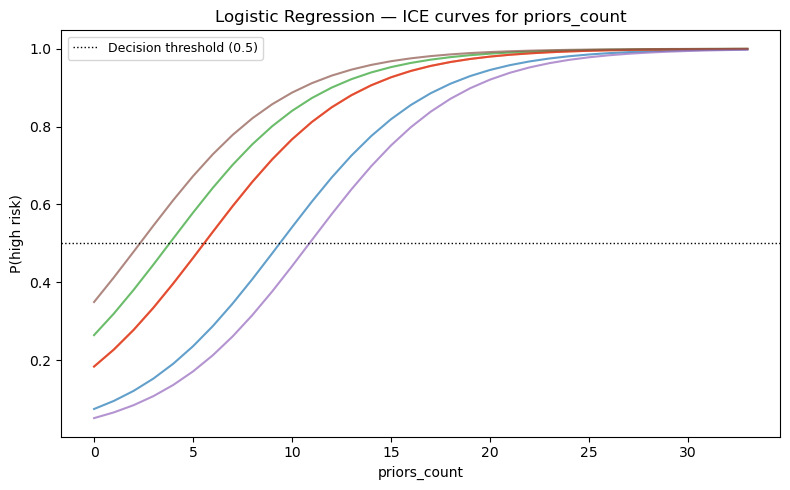

Saved: ice_priors_count.png


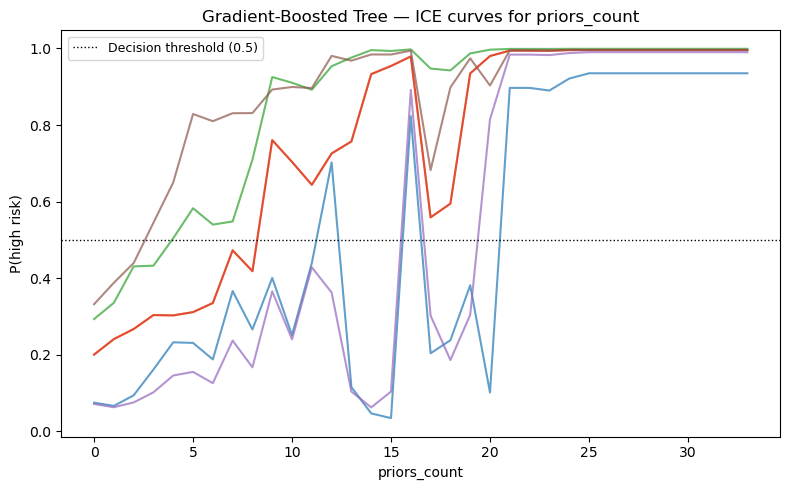

Saved: ice_priors_count.png


In [12]:
# ── Part D, Cell 2: ICE Curves for priors_count ───────────────────────────────
#
# Each line is a randomly sampled test-set defendant. The x-axis sweeps
# priors_count from its minimum to maximum observed value.
# A dashed horizontal line marks the 0.5 decision threshold.
#
# Parallel lines indicate a consistent additive effect — the model adds
# the same amount of risk regardless of the defendant's other features.
# Crossing or non-parallel lines indicate interaction effects — the
# impact of priors differs depending on other attributes, which in a
# logistic regression would be unexpected but which the GBT can produce.

priors_grid = np.arange(int(X_test['priors_count'].min()),
                        int(X_test['priors_count'].max()) + 1)

for name, model in models.items():
    plot_ice_numeric(
        model, X_test,
        feature_col  = 'priors_count',
        values       = priors_grid,
        n_instances  = 6,
        random_state = 42,
        title        = f'{name} — ICE curves for priors_count'
    )

In [13]:
# ── Part D, Cell 3: Global Sensitivity Index ──────────────────────────────────
#
# The sensitivity index is the variance of the population-average predicted
# probability as priors_count is swept across its full range.
# range_mean_score shows the absolute spread.
#
# A higher sensitivity index means priors_count has more global influence
# on the average predicted probability — which, combined with the known
# racial disparity in policing, is a concrete governance concern:
# the most influential predictor may encode systemic inequality.

sensitivity_rows = []
for name, model in models.items():
    sens = global_sensitivity_index(model, X_test, 'priors_count', priors_grid)
    sens['model'] = name
    sensitivity_rows.append(sens)

sensitivity_table = pd.concat(sensitivity_rows, ignore_index=True)
print('=== Part D: Global Sensitivity Index — priors_count ===')
print(sensitivity_table[['model', 'feature', 'sensitivity_index',
                           'min_mean_score', 'max_mean_score',
                           'range_mean_score']].round(6).to_string(index=False))

=== Part D: Global Sensitivity Index — priors_count ===
                model      feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score
  Logistic Regression priors_count           0.048791        0.287583        0.999167          0.711584
Gradient-Boosted Tree priors_count           0.041237        0.282523        0.980582          0.698059


### Part D — Interpretation

The stress test should show a smooth, monotone increase in mean predicted
probability as delta increases from 0 to 10. If the increase is non-monotone
for either model, it indicates sensitivity to specific ranges of prior counts
rather than a consistent directional effect.

The ICE curves for the logistic regression should be roughly parallel because
linear models produce additive effects by construction. Non-parallel ICE curves
on the GBT indicate that priors_count interacts with other features — meaning
the effect of an additional prior is larger for some defendants than others
depending on their race, age, or charge type.

The global sensitivity index translates the ICE picture into a single governance
number. A large range_mean_score (e.g. > 0.2) means that the model's average
predicted score moves by more than 20 percentage points across the observed
range of prior counts — confirming that `priors_count` is the dominant lever
in the model's decisions, and that any systemic racial disparity in its
measurement will propagate directly into disparate risk scores.

---
## Part E — Slice-Based Evaluation

Slice-based evaluation computes accuracy, AUC, Brier score, FPR, and FNR
separately for each demographic subgroup. A well-behaved model should show
consistent performance across slices. Disparate FPR across racial groups is
the central finding from ProPublica's original analysis, and replicating it
here with the sklearn pipelines confirms that the behaviour is not an artifact
of the statsmodels implementation in HW1–HW3.

In [14]:
# ── Part E, Cell 1: Slice Metrics by Race, Gender, and Age ────────────────────
#
# I evaluate both models across three demographic dimensions:
#   race_factor   — 6 groups; primary fairness axis for the COMPAS audit
#   gender_factor — Male / Female
#   age_factor    — Less than 25 / 25-45 / Greater than 45
#
# Key metrics:
#   fpr — false positive rate: non-recidivists flagged high-risk
#   fnr — false negative rate: actual recidivists missed
#   auc — discriminative ability within the slice
#
# A finding of higher FPR for African-American defendants than Caucasian
# defendants, combined with lower FNR, replicates the ProPublica racial
# bias finding and provides evidence that the sklearn pipeline is
# consistent with the statsmodels logistic regression from HW1.

slice_features = ['race_factor', 'gender_factor', 'age_factor']

for name, model in models.items():
    tbls  = [slice_metrics(model, X_test, y_test, col) for col in slice_features]
    seval = (
        pd.concat(tbls, ignore_index=True)
        .sort_values(['slice_feature', 'n'], ascending=[True, False])
    )
    print(f'\n=== Part E: Slice-Based Evaluation — {name} ===')
    print(seval.round(4).to_string(index=False))


=== Part E: Slice-Based Evaluation — Logistic Regression ===
slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  mean_score
   age_factor          25 - 45  695    0.7583 0.8326 0.1625 0.1658 0.3366      0.4611
   age_factor  Greater than 45  272    0.8272 0.8492 0.1307 0.0498 0.5211      0.2300
   age_factor     Less than 25  268    0.6604 0.7175 0.2023 0.6633 0.1529      0.6338
gender_factor             Male 1000    0.7620 0.8448 0.1589 0.2135 0.2677      0.4636
gender_factor           Female  235    0.7106 0.7832 0.1865 0.1606 0.4694      0.3797
  race_factor African-American  634    0.7366 0.8195 0.1719 0.3870 0.1769      0.5880
  race_factor        Caucasian  412    0.7500 0.7939 0.1626 0.1092 0.5625      0.3168
  race_factor         Hispanic  108    0.8241 0.8311 0.1379 0.0633 0.4828      0.3029
  race_factor            Other   71    0.8028 0.8524 0.1400 0.0185 0.7647      0.2009
  race_factor            Asian    8    0.7500 0.6667 0.2027 0.0000 1.0000     

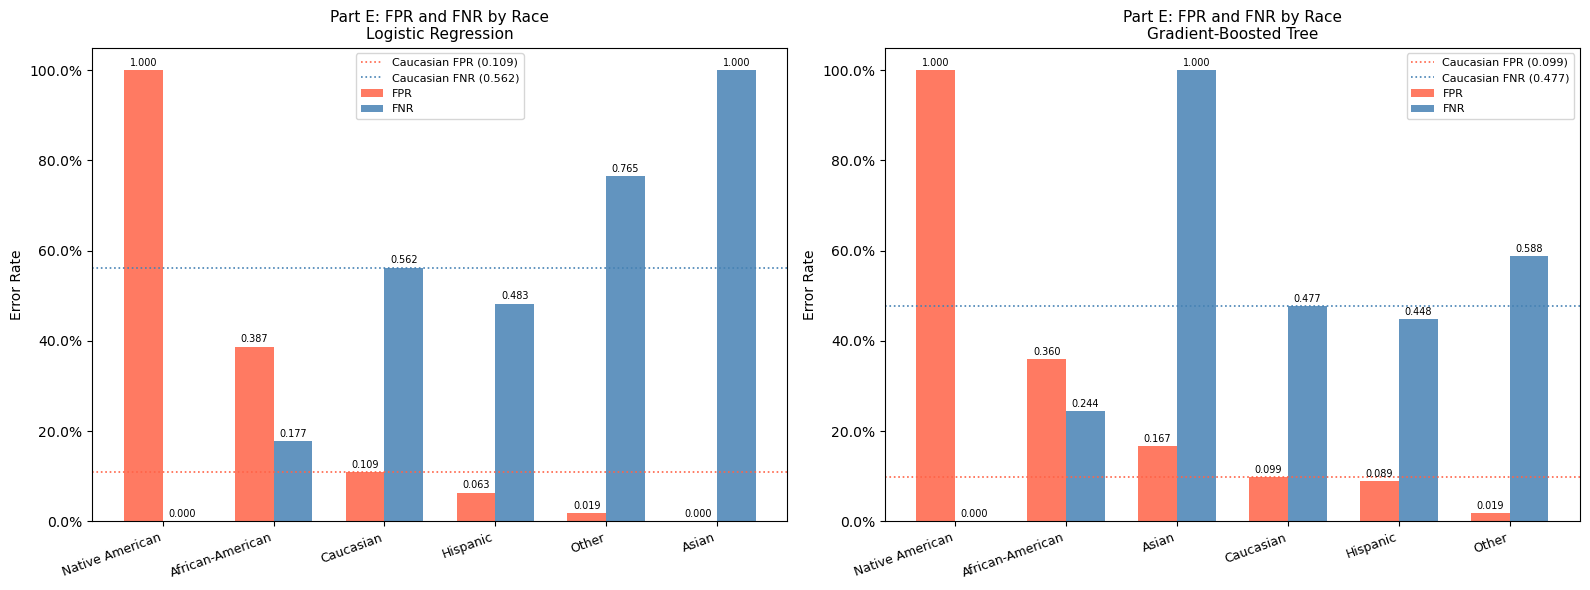

Saved: slice_fpr_fnr_by_race.png


In [15]:
# ── Part E, Cell 2: FPR / FNR Bar Charts by Race ─────────────────────────────
#
# Side-by-side grouped bar charts showing FPR and FNR by racial group
# for both models. Sorted by FPR descending so the most affected group
# appears on the left. Reference lines mark Caucasian FPR and FNR.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, model) in zip(axes, models.items()):
    rs = (slice_metrics(model, X_test, y_test, 'race_factor')
          .sort_values('fpr', ascending=False).reset_index(drop=True))

    cau_fpr = rs.loc[rs['slice_value'] == 'Caucasian', 'fpr'].values[0]
    cau_fnr = rs.loc[rs['slice_value'] == 'Caucasian', 'fnr'].values[0]

    x, w = np.arange(len(rs)), 0.35
    b1 = ax.bar(x - w/2, rs['fpr'], w, color='tomato',    alpha=0.85, label='FPR')
    b2 = ax.bar(x + w/2, rs['fnr'], w, color='steelblue', alpha=0.85, label='FNR')

    ax.axhline(cau_fpr, color='tomato',    linestyle=':', linewidth=1.2,
               label=f'Caucasian FPR ({cau_fpr:.3f})')
    ax.axhline(cau_fnr, color='steelblue', linestyle=':', linewidth=1.2,
               label=f'Caucasian FNR ({cau_fnr:.3f})')

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(rs['slice_value'], rotation=20, ha='right', fontsize=9)
    ax.set_ylabel('Error Rate')
    ax.set_title(f'Part E: FPR and FNR by Race\n{name}', fontsize=11)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

plt.tight_layout()
plt.savefig('slice_fpr_fnr_by_race.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: slice_fpr_fnr_by_race.png')

### Part E — Interpretation

The central finding should replicate the ProPublica result: African-American
defendants have a substantially higher FPR than Caucasian defendants, meaning
Black non-recidivists are flagged high-risk at a higher rate. Simultaneously,
the FNR for African-American defendants should be lower, meaning fewer actual
Black recidivists are missed. This pattern — higher false positives and lower
false negatives for Black defendants versus the reverse for White defendants —
is the specific form of error-rate disparity identified in the ProPublica
investigation and is inconsistent with equalized odds.

Comparing the two models on this dimension is instructive: if the GBT shows
a larger FPR gap than the logistic regression, it means the additional model
capacity amplified the racial disparity rather than correcting it. This would
be a strong argument against deploying the GBT without explicit fairness
constraints.

Age-based slices should show the youngest defendants (Less than 25) with
the highest mean scores and the highest share flagged high-risk, consistent
with the 2.5× relative risk identified in HW1.

---
## Audit Summary

The table below consolidates the key quantitative findings across all five parts
for reference.

In [16]:
# ── Compact Audit Summary Table ───────────────────────────────────────────────

summary_rows = []

# Part A
for _, row in input_drift_table.iterrows():
    summary_rows.append({'part': 'A — Drift',          'item': row['feature'],
                         'metric_1': 'PSI',  'value_1': row['PSI'],
                         'metric_2': 'KS_p', 'value_2': row['KS_pvalue']})
summary_rows.append({'part': 'A — Drift', 'item': 'encoded_features',
                     'metric_1': 'MMD^2', 'value_1': mmd_val,
                     'metric_2': '',       'value_2': np.nan})

# Part B
for _, row in generalization_table.iterrows():
    summary_rows.append({'part': 'B — Generalization', 'item': row['model'],
                         'metric_1': 'AUC_gap',      'value_1': row['auc_gap'],
                         'metric_2': 'Accuracy_gap', 'value_2': row['accuracy_gap']})

# Part D
for _, row in sensitivity_table.iterrows():
    summary_rows.append({'part': 'D — Robustness', 'item': row['model'],
                         'metric_1': 'Sensitivity_idx',  'value_1': row['sensitivity_index'],
                         'metric_2': 'Range_mean_score', 'value_2': row['range_mean_score']})

summary = pd.DataFrame(summary_rows)
print('=== HW4 Audit Summary ===')
print(summary.round(6).to_string(index=False))

=== HW4 Audit Summary ===
              part                  item        metric_1   value_1         metric_2  value_2
         A — Drift          priors_count             PSI  0.010355             KS_p 0.211300
         A — Drift        two_year_recid             PSI  0.000820             KS_p 0.986200
         A — Drift      encoded_features           MMD^2 -0.000272                       NaN
B — Generalization   Logistic Regression         AUC_gap -0.003700     Accuracy_gap 0.001700
B — Generalization Gradient-Boosted Tree         AUC_gap  0.024500     Accuracy_gap 0.025000
    D — Robustness   Logistic Regression Sensitivity_idx  0.048791 Range_mean_score 0.711584
    D — Robustness Gradient-Boosted Tree Sensitivity_idx  0.041237 Range_mean_score 0.698059
